# Content

This code focuses on predicting Samsung stock prices using **LSTM models** for time-series forecasting. It implements two primary models:

---

#### **1. Single Input LSTM Model**
- **Structure**:
  - One LSTM layer (32 units, ReLU activation) to process sequential features.
  - Dense layers for further feature extraction and output (16 units + 1 unit for final prediction).
- **Training**:
  - Trained for 20 epochs with a batch size of 16.
  - Input sequences were prepared using a sliding window of 20 days, mapping them to the target (closing prices).
- **Purpose**:
  - Captures sequential patterns in stock price movements to predict the next closing price.

---

#### **2. Multi-Input LSTM Model**
- **Structure**:
  - Two parallel LSTM branches (64 units each, ReLU activation) to process identical inputs independently.
  - Outputs are merged via a concatenation layer, followed by Dense layers to make a single prediction.
- **Purpose**:
  - Designed to experiment with multi-branch architectures, potentially improving feature representation.

---

#### **Evaluation**
- Both models' predictions were compared against actual prices using metrics like **MSE** and visualized with `true vs. predicted` graphs.
- Training performance was analyzed through loss and MSE curves, showing the models' learning progression.

---

#### **Key Takeaways**
- **Strengths**: The LSTM models effectively capture temporal dependencies in stock prices.
- **Weaknesses**:
  - Multi-input architecture adds complexity without clear benefits since identical inputs were used.
  - Generalization may be limited due to reliance on a single stock dataset.

This code serves as a strong introduction to LSTM-based time-series forecasting, highlighting how sequential data is processed and modeled for predictive tasks.

# Basic setting

### Measuring execution time

In [114]:
!pip install --q ipython-autotime
%load_ext autotime

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 5.57 s (started: 2025-01-24 01:04:28 +00:00)


### Library

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras

time: 700 µs (started: 2025-01-24 01:04:33 +00:00)


# Data collection

### Load data from URL

In [116]:
data_url = 'https://raw.githubusercontent.com/20161609/data_box/refs/heads/main/005930.KS.csv'

df = pd.read_csv(data_url)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-06-22,59000.0,59100.0,57600.0,57600.0,56180.625000,23334687
1,2022-06-23,57700.0,58000.0,56800.0,57400.0,55985.550781,28338608
2,2022-06-24,57900.0,59100.0,57700.0,58400.0,56960.914063,23256103
3,2022-06-27,59000.0,59900.0,58300.0,58800.0,57351.058594,18122236
4,2022-06-28,59200.0,59500.0,58700.0,59400.0,57936.269531,13540538


time: 217 ms (started: 2025-01-24 01:04:34 +00:00)


### Modify col names so that it can be easily referenced.

In [117]:
df.columns = [col.replace(' ', '_').lower() for col in df.columns]
df.head()

,date,open,high,low,close,adj_close,volume
0,2022-06-22,59000.0,59100.0,57600.0,57600.0,56180.625000,23334687
1,2022-06-23,57700.0,58000.0,56800.0,57400.0,55985.550781,28338608
2,2022-06-24,57900.0,59100.0,57700.0,58400.0,56960.914063,23256103
3,2022-06-27,59000.0,59900.0,58300.0,58800.0,57351.058594,18122236
4,2022-06-28,59200.0,59500.0,58700.0,59400.0,57936.269531,13540538


time: 22.1 ms (started: 2025-01-24 01:04:34 +00:00)


### Data information

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       249 non-null    object 
 1   open       249 non-null    float64
 2   high       249 non-null    float64
 3   low        249 non-null    float64
 4   close      249 non-null    float64
 5   adj_close  249 non-null    float64
 6   volume     249 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 13.7+ KB
time: 6.31 ms (started: 2025-01-24 01:04:34 +00:00)


In [119]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
open,249.0,6.134257e+04,4.218292e+03,52300.000000,5.860000e+04,6.090000e+04,6.350000e+04,72700.0
high,249.0,6.183896e+04,4.132333e+03,53600.000000,5.920000e+04,6.140000e+04,6.370000e+04,72700.0
low,249.0,6.080080e+04,4.164820e+03,51800.000000,5.810000e+04,6.040000e+04,6.260000e+04,71600.0
close,249.0,6.130763e+04,4.185640e+03,52600.000000,5.880000e+04,6.080000e+04,6.320000e+04,72300.0
adj_close,249.0,6.073860e+04,4.482216e+03,51911.933594,5.770174e+04,6.015167e+04,6.293555e+04,72300.0
volume,249.0,1.245450e+07,5.641251e+06,28613.000000,9.618009e+06,1.277972e+07,1.533118e+07,28338608.0


time: 74.5 ms (started: 2025-01-24 01:04:34 +00:00)


In [120]:
df[df['volume'] == 0]

,date,open,high,low,close,adj_close,volume


time: 111 ms (started: 2025-01-24 01:04:34 +00:00)


# Data preprocessing

### Volume is Zero

In [121]:
df.loc[df['volume'] == 0, 'volume'] = np.nan
df.isna().sum()

,0
date,0
open,0
high,0
low,0
close,0
adj_close,0
volume,0


time: 34.4 ms (started: 2025-01-24 01:04:34 +00:00)


### Missing value

In [122]:
df = df.dropna()
df.isna().sum()

,0
date,0
open,0
high,0
low,0
close,0
adj_close,0
volume,0


time: 53.9 ms (started: 2025-01-24 01:04:34 +00:00)


### The type of Datetime

In [123]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       249 non-null    datetime64[ns]
 1   open       249 non-null    float64       
 2   high       249 non-null    float64       
 3   low        249 non-null    float64       
 4   close      249 non-null    float64       
 5   adj_close  249 non-null    float64       
 6   volume     249 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 13.7 KB
time: 72.2 ms (started: 2025-01-24 01:04:34 +00:00)


### Setting index: Date

In [124]:
df = df.set_index('date')
df.head()

,open,high,low,close,adj_close,volume
date,,,,,,
2022-06-22,59000.0,59100.0,57600.0,57600.0,56180.625000,23334687.0
2022-06-23,57700.0,58000.0,56800.0,57400.0,55985.550781,28338608.0
2022-06-24,57900.0,59100.0,57700.0,58400.0,56960.914063,23256103.0
2022-06-27,59000.0,59900.0,58300.0,58800.0,57351.058594,18122236.0
2022-06-28,59200.0,59500.0,58700.0,59400.0,57936.269531,13540538.0


time: 242 ms (started: 2025-01-24 01:04:34 +00:00)


### Visualization

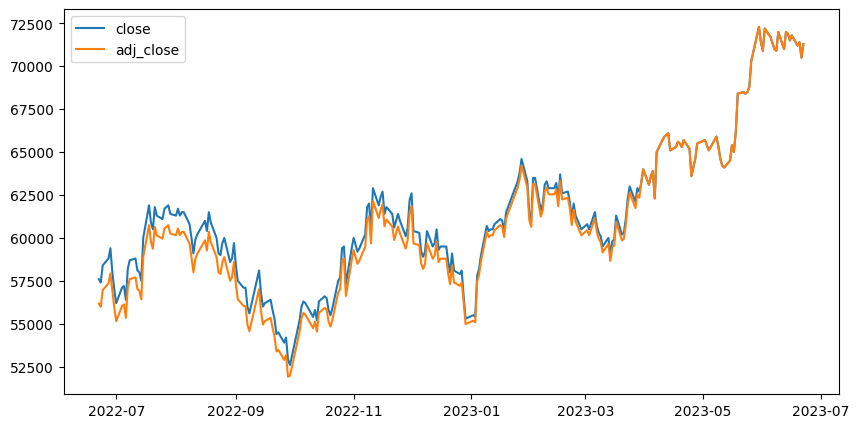

time: 1.09 s (started: 2025-01-24 01:04:35 +00:00)


In [125]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['close'], label='close')
plt.plot(df.index, df['adj_close'], label='adj_close')
plt.legend()
plt.show()

### Add moving averages (MA3 and MA5) columns

In [126]:
df['ma3'] = np.around(df['close'].rolling(window=3).mean(), 0)
df['ma5'] = np.around(df['close'].rolling(window=5).mean(),0)
df.head()

,open,high,low,close,adj_close,volume,ma3,ma5
date,,,,,,,,
2022-06-22,59000.0,59100.0,57600.0,57600.0,56180.625000,23334687.0,NaN,NaN
2022-06-23,57700.0,58000.0,56800.0,57400.0,55985.550781,28338608.0,NaN,NaN
2022-06-24,57900.0,59100.0,57700.0,58400.0,56960.914063,23256103.0,57800.0,NaN
2022-06-27,59000.0,59900.0,58300.0,58800.0,57351.058594,18122236.0,58200.0,NaN
2022-06-28,59200.0,59500.0,58700.0,59400.0,57936.269531,13540538.0,58867.0,58320.0


time: 47.8 ms (started: 2025-01-24 01:04:36 +00:00)


### Calculate the mid-price between 'low' and 'high'

In [127]:
df['mid'] = (df['low'] + df['high'])/2
df.head()

,open,high,low,close,adj_close,volume,ma3,ma5,mid
date,,,,,,,,,
2022-06-22,59000.0,59100.0,57600.0,57600.0,56180.625000,23334687.0,NaN,NaN,58350.0
2022-06-23,57700.0,58000.0,56800.0,57400.0,55985.550781,28338608.0,NaN,NaN,57400.0
2022-06-24,57900.0,59100.0,57700.0,58400.0,56960.914063,23256103.0,57800.0,NaN,58400.0
2022-06-27,59000.0,59900.0,58300.0,58800.0,57351.058594,18122236.0,58200.0,NaN,59100.0
2022-06-28,59200.0,59500.0,58700.0,59400.0,57936.269531,13540538.0,58867.0,58320.0,59100.0


time: 107 ms (started: 2025-01-24 01:04:36 +00:00)


### Missing values after adding new columns

In [128]:
df = df.dropna()
df.isna().sum()

,0
open,0
high,0
low,0
close,0
adj_close,0
volume,0
ma3,0
ma5,0
mid,0


time: 21.9 ms (started: 2025-01-24 01:04:36 +00:00)


# Data preparation

### Split: train and test

In [129]:
idx = int(df.shape[0]*0.8)

train = df.iloc[:idx, :]
test = df.iloc[idx: , :]

train.shape, test.shape

((196, 9), (49, 9))

time: 9.33 ms (started: 2025-01-24 01:04:36 +00:00)


### Split: features and target

In [130]:
X_train = train.drop(['close', 'adj_close'], axis=1)
y_train = train['close']

X_train.shape, y_train.shape

((196, 7), (196,))

time: 9.83 ms (started: 2025-01-24 01:04:36 +00:00)


### Normalize features

In [131]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()
X_train_s = ms.fit_transform(X_train)
y_train = y_train.to_numpy()

X_train_s.shape, y_train.shape

((196, 7), (196,))

time: 21.8 ms (started: 2025-01-24 01:04:36 +00:00)


### Sequences for time series forecasting

In [132]:
def make_sequence_dataset(X, y, window_size):
    feature_list = []
    label_list = []

    for i in range(len(X) - window_size):
        feature_list.append(X[i:i+window_size])
        label_list.append(y[i+window_size])

    return np.array(feature_list), np.array(label_list)

# Generate sequences for training data
X_train_w, y_train_w = make_sequence_dataset(X_train_s, y_train, 20)
print(X_train_w.shape, y_train_w.shape)

(176, 20, 7) (176,)
time: 6.71 ms (started: 2025-01-24 01:04:36 +00:00)


# Model

### Create model

In [133]:
from keras import layers

model = keras.Sequential()
model.add(layers.LSTM(32,  activation='relu', input_shape=(20, 7)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1))

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 32)                  │           5,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,665 (22.13 KB)

 Trainable params: 5,665 (22.13 KB)

 Non-trainable params: 0 (0.00 B)

time: 180 ms (started: 2025-01-24 01:04:36 +00:00)


### Compile model

In [134]:
model.compile(
    loss = 'mse',
    optimizer  = 'adam',
    metrics=['mse', 'mae']
)

time: 7.82 ms (started: 2025-01-24 01:04:36 +00:00)


### History

In [135]:
EPOCHS = 20
BATCH_SIZE = 16

history = model.fit(X_train_w, y_train_w,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_split=0.2)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 156ms/step - loss: 3529048064.0000 - mae: 59348.6562 - mse: 3529048064.0000 - val_loss: 3810999808.0000 - val_mae: 61713.1602 - val_mse: 3810999808.0000
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 3523072512.0000 - mae: 59298.6797 - mse: 3523072512.0000 - val_loss: 3810900736.0000 - val_mae: 61712.3594 - val_mse: 3810900736.0000
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 3531783168.0000 - mae: 59377.7031 - mse: 3531783168.0000 - val_loss: 3810417920.0000 - val_mae: 61708.4531 - val_mse: 3810417920.0000
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 3531082752.0000 - mae: 59365.4102 - mse: 3531082752.0000 - val_loss: 3789483520.0000 - val_mae: 61538.0977 - val_mse: 3789483520.0000
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 3435781888.0000 - mae: 58555.6172 - mse: 3435781888.0000 - val_loss: 3382181376.0000 - val_mae: 58116.0703 - val_mse: 3382181376.0000
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/

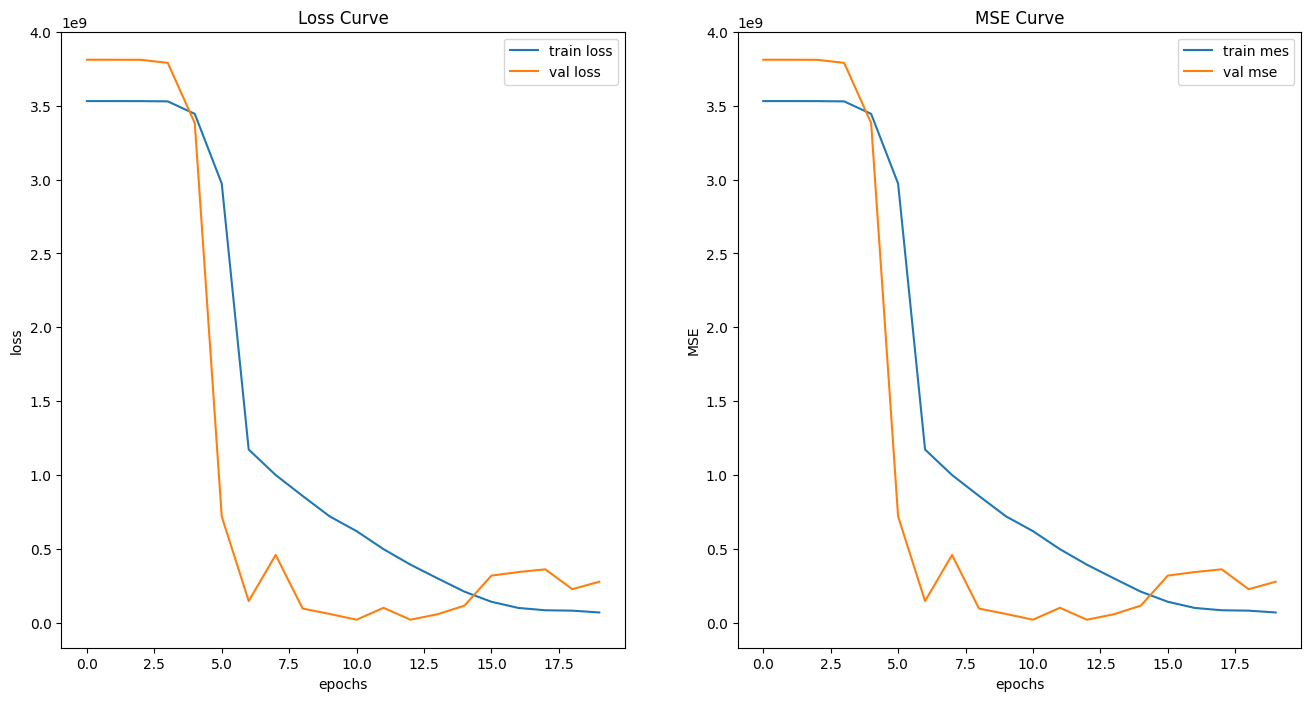

time: 890 ms (started: 2025-01-24 01:04:53 +00:00)


In [136]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.plot(hist['epoch'], hist['loss'], label='train loss')
    plt.plot(hist['epoch'], hist['val_loss'], label='val loss')
    plt.title('Loss Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.xlabel('epochs')
    plt.ylabel('MSE')
    plt.plot(hist['epoch'], hist['mse'], label='train mes')
    plt.plot(hist['epoch'], hist['val_mse'], label='val mse')
    plt.title('MSE Curve')
    plt.legend()
    plt.show()

plot_history(history)

# Estimate

### Split(test data): featrues and target

In [137]:
X_test = test.drop(['close', 'adj_close'], axis=1)
y_test = test['close']

X_test.shape, y_test.shape

((49, 7), (49,))

time: 4.41 ms (started: 2025-01-24 01:04:54 +00:00)


### Scailing

In [138]:
X_test_s = ms.transform(X_test)
y_test = y_test.to_numpy()

X_test_s.shape, y_test.shape

((49, 7), (49,))

time: 37 ms (started: 2025-01-24 01:04:54 +00:00)


### Sequences for time series forecasting

In [139]:
X_test_w, y_test_w = make_sequence_dataset(X_test_s, y_test, 20)

X_test_w.shape, y_test_w.shape

((29, 20, 7), (29,))

time: 10.4 ms (started: 2025-01-24 01:04:54 +00:00)


### Prediction

In [140]:
y_pred = model.predict(X_test_w)

y_pred[:5:]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step


array([[89949.4 ],
       [88544.65],
       [87601.73],
       [85366.39],
       [81744.18]], dtype=float32)

time: 533 ms (started: 2025-01-24 01:04:54 +00:00)


### Visualization of perfomance

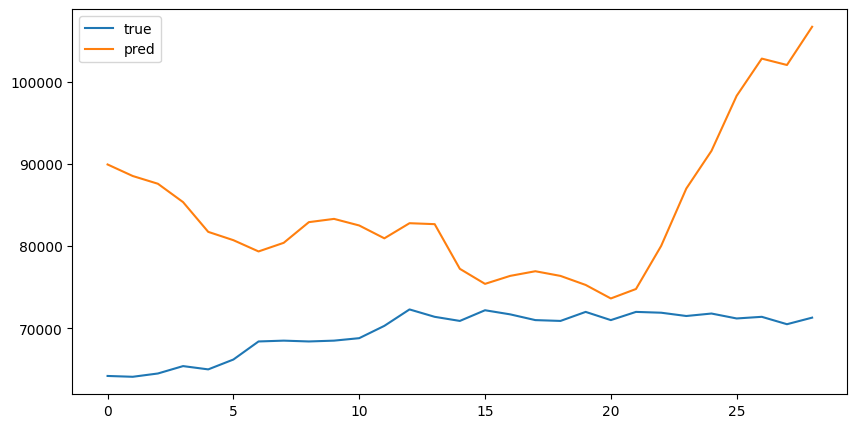

time: 415 ms (started: 2025-01-24 01:04:54 +00:00)


In [141]:
plt.figure(figsize=(10, 5))
plt.plot(y_test_w, label='true')
plt.plot(y_pred.flatten(), label='pred')
plt.legend()
plt.show()

# Model2: including 2 inputs.

### 1st input

In [142]:
input1 = layers.Input(shape=(20, 7))
x = layers.LSTM(64, activation='relu')(input1)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(132, activation='relu')(x)
output1 = layers.Dense(32, activation='relu')(x)

time: 65.8 ms (started: 2025-01-24 01:04:55 +00:00)


### 2nd input

In [143]:
input2 = layers.Input(shape=(20, 7))
x = layers.LSTM(64, activation='relu')(input2)
output2 = layers.Dense(32, activation='relu')(x)

time: 53.3 ms (started: 2025-01-24 01:04:55 +00:00)


### Create model

In [144]:
merge = layers.Concatenate()([output1, output2])
output3 = layers.Dense(1)(merge)

model = keras.Model(inputs=[input1, input2], outputs=output3)

model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 20, 7)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_6 (LSTM)             │ (None, 64)             │         18,432 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_13 (Dense)          │ (None, 32)             │          2,080 │ lstm_6[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_7             │ (None, 20, 7)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_14 (Dense)          │ (None, 132)            │          4,356 │ dense_13[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_7 (LSTM)             │ (None, 64)             │         18,432 │ input_layer_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_15 (Dense)          │ (None, 32)             │          4,256 │ dense_14[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_16 (Dense)          │ (None, 32)             │          2,080 │ lstm_7[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 64)             │              0 │ dense_15[0][0],        │
│ (Concatenate)             │                        │                │ dense_16[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_17 (Dense)          │ (None, 1)              │             65 │ concatenate_1[0][0]    │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 49,701 (194.14 KB)

 Trainable params: 49,701 (194.14 KB)

 Non-trainable params: 0 (0.00 B)

time: 55.2 ms (started: 2025-01-24 01:04:55 +00:00)


### Model architecture

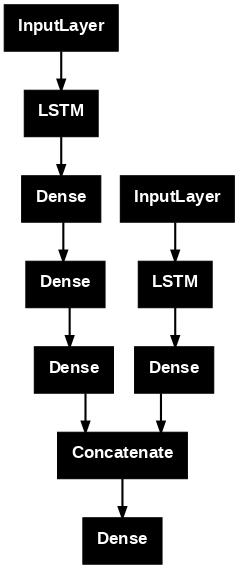

time: 123 ms (started: 2025-01-24 01:04:55 +00:00)


In [145]:
keras.utils.plot_model(model, dpi=76)

### Compile model

In [146]:
model.compile(loss='mse', optimizer='adam', metrics=['mse'])

time: 13.1 ms (started: 2025-01-24 01:04:55 +00:00)


### Learning

In [147]:
model.fit(
    [X_train_w, X_train_w], y_train_w,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - loss: 3509569792.0000 - mse: 3509569792.0000 - val_loss: 3810999296.0000 - val_mse: 3810999296.0000
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 3512588800.0000 - mse: 3512588800.0000 - val_loss: 3810632448.0000 - val_mse: 3810632448.0000
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 3547278336.0000 - mse: 3547278336.0000 - val_loss: 3762167040.0000 - val_mse: 3762167040.0000
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 3296470528.0000 - mse: 3296470528.0000 - val_loss: 925097344.0000 - val_mse: 925097344.0000
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 1398796672.0000 - mse: 1398796672.0000 - val_loss: 437694272.0000 - val_mse: 437694272.0000
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 1321334144.0000 - mse: 1321334144.0000 - val_loss: 93259336.0000 - val_mse: 93259336.0000
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 1031642496.0000 - mse: 1031642496.0000 - val

time: 59 s (started: 2025-01-24 01:04:55 +00:00)


# Estimate: Model2

### Prediction

In [148]:
y_pred = model.predict([X_test_w, X_test_w])
y_pred[:5:]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step


array([[101767.18],
       [100737.28],
       [ 99379.55],
       [ 96653.95],
       [ 92737.92]], dtype=float32)

time: 479 ms (started: 2025-01-24 01:05:54 +00:00)


### Visualization of perfomance

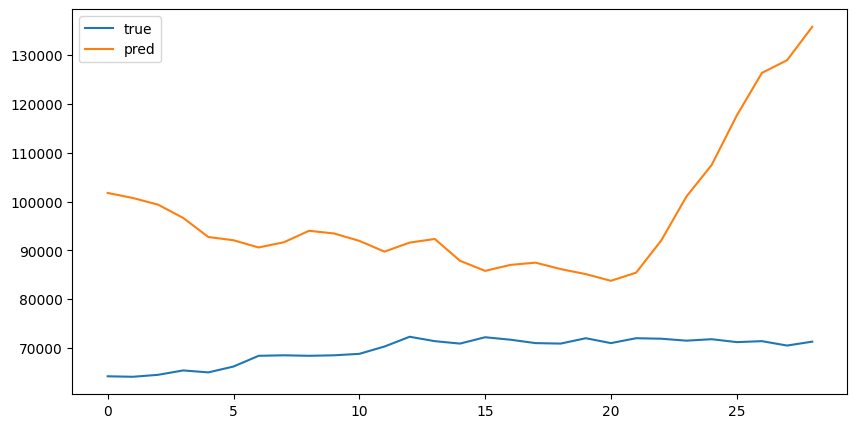

time: 196 ms (started: 2025-01-24 01:05:55 +00:00)


In [149]:
plt.figure(figsize=(10, 5))
plt.plot(y_test_w, label='true')
plt.plot(y_pred.flatten(), label='pred')
plt.legend()
plt.show()